In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
print("Libraries loaded.")

Libraries loaded.


In [ ]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
print("Shape:", df.shape)
df.head()

Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
# PROJECT QUESTION
# Can we predict whether a patient is at risk of having a stroke
# based on demographic and clinical features such as age, BMI,
# average glucose level, hypertension, and lifestyle factors?
print("Project question defined.")

Project question defined.


In [ ]:
print("=== Shape ===")
print(df.shape)

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicates ===")
print("Duplicate rows:", df.duplicated().sum())

print("\n=== Basic Stats ===")
df.describe()

=== Shape ===
(5110, 12)

=== Data Types ===
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

=== Missing Values ===
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

=== Duplicates ===
Duplicate rows: 0

=== Basic Stats ===


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [ ]:
# ── 1. Drop 'id' column (not a feature) ──
df.drop(columns=['id'], inplace=True)
print("Dropped 'id' column.")

# ── 2. Handle missing BMI values (fill with median) ──
bmi_median = df['bmi'].median()
df['bmi'].fillna(bmi_median, inplace=True)
print(f"Filled {df['bmi'].isnull().sum()} missing BMI values with median: {bmi_median:.2f}")

# ── 3. Drop 'Unknown' gender row (only 1 record) ──
df = df[df['gender'] != 'Unknown']
print("Removed 'Unknown' gender row.")

# ── 4. Fix data types ──
df['age'] = df['age'].astype(int)
print("Converted age to int.")

# ── 5. Verify no remaining nulls ──
print("\nRemaining nulls:")
print(df.isnull().sum())
print("\nCleaned dataset shape:", df.shape)

Dropped 'id' column.
Filled 0 missing BMI values with median: 28.10
Removed 'Unknown' gender row.
Converted age to int.

Remaining nulls:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Cleaned dataset shape: (5110, 11)


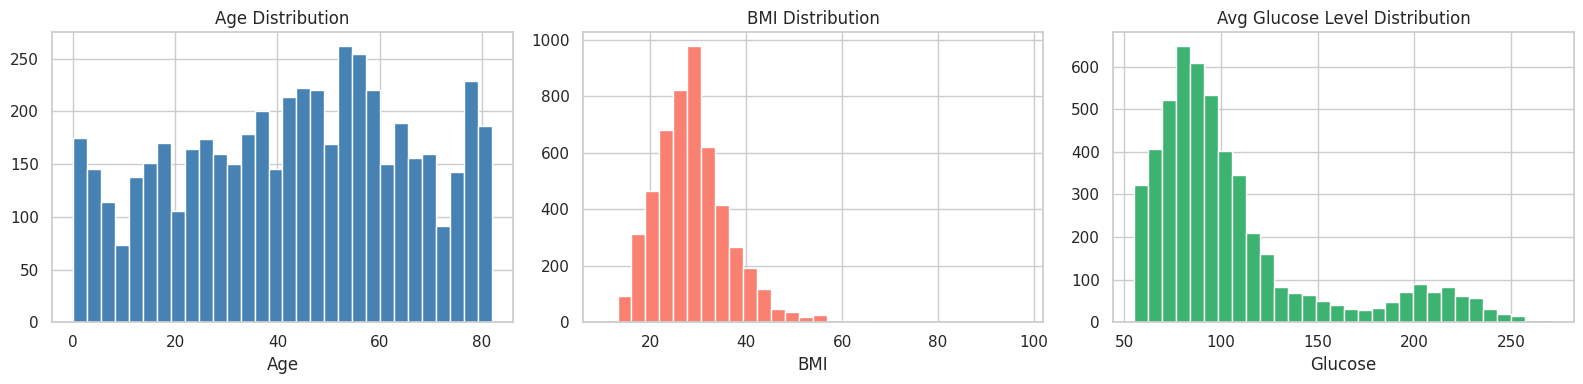

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Age distribution
axes[0].hist(df['age'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

# BMI distribution
axes[1].hist(df['bmi'], bins=30, color='salmon', edgecolor='white')
axes[1].set_title('BMI Distribution')
axes[1].set_xlabel('BMI')

# Avg glucose distribution
axes[2].hist(df['avg_glucose_level'], bins=30, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Avg Glucose Level Distribution')
axes[2].set_xlabel('Glucose')

plt.tight_layout()
plt.savefig('plot1_univariate_numeric.png', dpi=150)
plt.show()

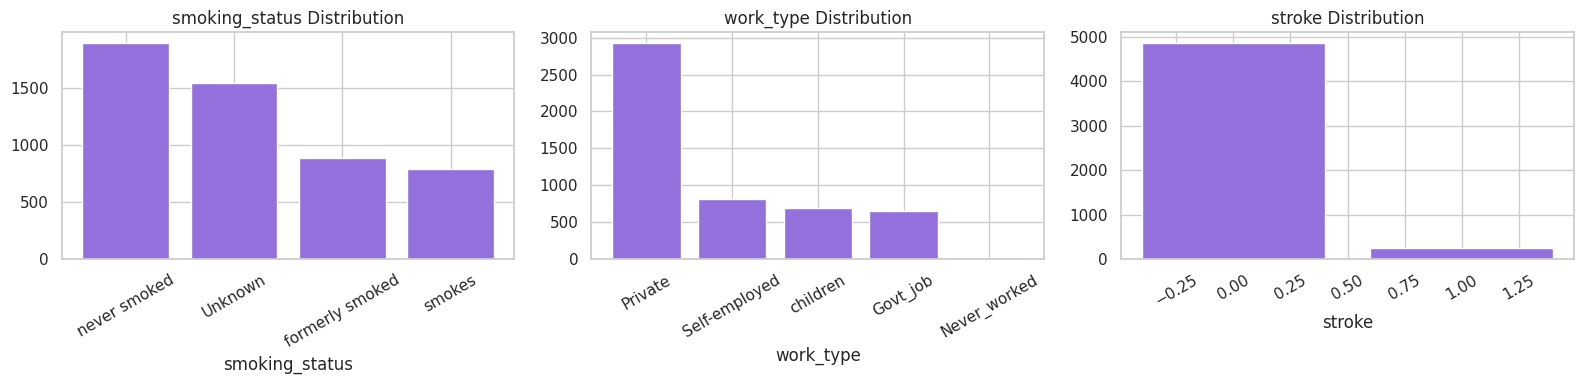


Class imbalance check:
stroke
0    4861
1     249
Name: count, dtype: int64
Stroke rate: 4.87%


In [ ]:
# Univariate Analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['smoking_status', 'work_type', 'stroke']):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color='mediumpurple', edgecolor='white')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('plot2_univariate_categorical.png', dpi=150)
plt.show()

print("\nClass imbalance check:")
print(df['stroke'].value_counts())
print(f"Stroke rate: {df['stroke'].mean()*100:.2f}%")

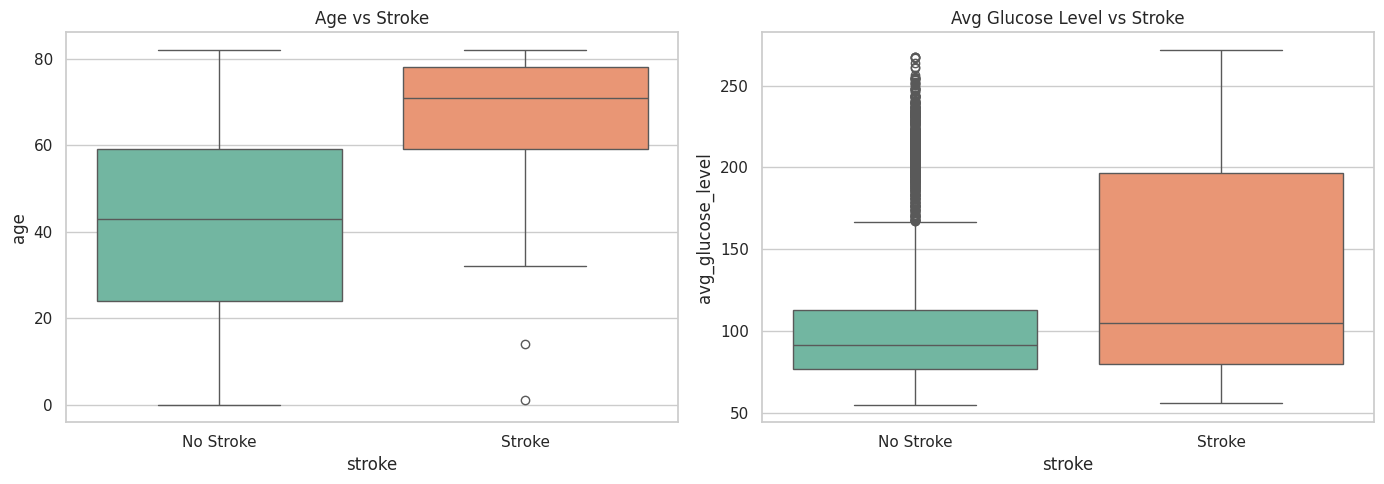

In [ ]:
# Bivariate Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age vs Stroke
sns.boxplot(x='stroke', y='age', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Age vs Stroke')
axes[0].set_xticklabels(['No Stroke', 'Stroke'])

# Glucose vs Stroke
sns.boxplot(x='stroke', y='avg_glucose_level', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Avg Glucose Level vs Stroke')
axes[1].set_xticklabels(['No Stroke', 'Stroke'])

plt.tight_layout()
plt.savefig('plot3_bivariate_boxplots.png', dpi=150)
plt.show()

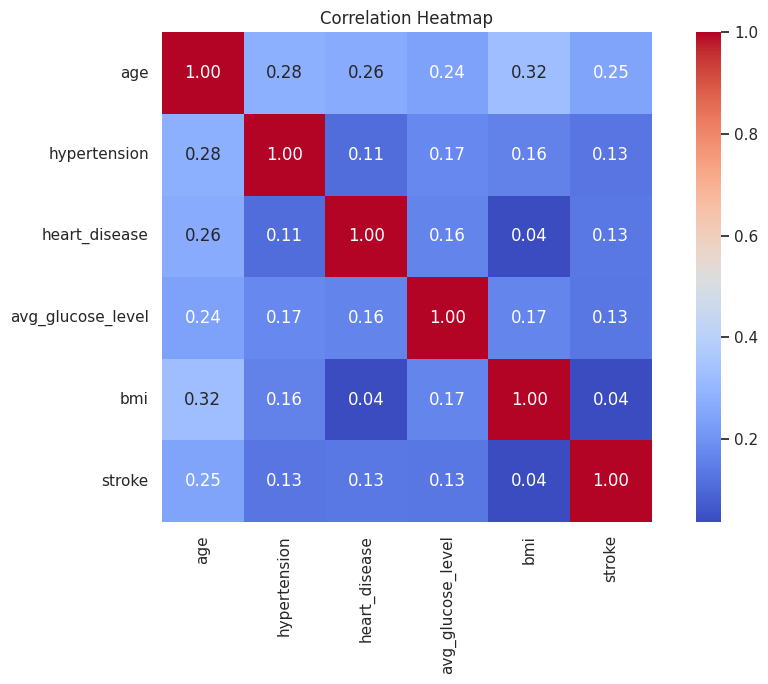

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('plot4_heatmap.png', dpi=150)
plt.show()

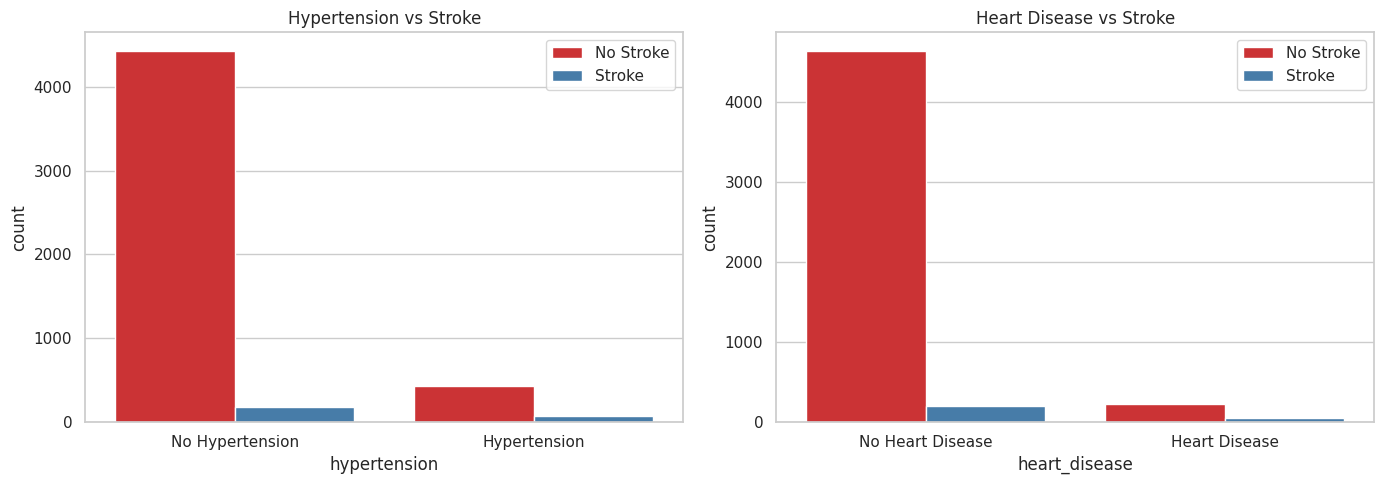

In [ ]:
# Categorical vs Stroke (count plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='hypertension', hue='stroke', data=df, ax=axes[0], palette='Set1')
axes[0].set_title('Hypertension vs Stroke')
axes[0].set_xticklabels(['No Hypertension', 'Hypertension'])
axes[0].legend(['No Stroke', 'Stroke'])

sns.countplot(x='heart_disease', hue='stroke', data=df, ax=axes[1], palette='Set1')
axes[1].set_title('Heart Disease vs Stroke')
axes[1].set_xticklabels(['No Heart Disease', 'Heart Disease'])
axes[1].legend(['No Stroke', 'Stroke'])

plt.tight_layout()
plt.savefig('plot5_countplots.png', dpi=150)
plt.show()

In [ ]:
# ── New Feature 1: BMI Category ──
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['bmi_category'] = df['bmi'].apply(bmi_category)

# ── New Feature 2: Age Group ──
def age_group(age):
    if age < 18:
        return 'Minor'
    elif age < 40:
        return 'Young Adult'
    elif age < 60:
        return 'Middle Aged'
    else:
        return 'Senior'

df['age_group'] = df['age'].apply(age_group)

# ── New Feature 3: Risk Score (hypertension + heart_disease + age>50) ──
df['risk_score'] = df['hypertension'] + df['heart_disease'] + (df['age'] > 50).astype(int)

print("New features added:")
print(df[['bmi_category', 'age_group', 'risk_score']].head())

New features added:
  bmi_category    age_group  risk_score
0        Obese       Senior           2
1   Overweight       Senior           1
2        Obese       Senior           2
3        Obese  Middle Aged           0
4       Normal       Senior           2


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

# ── Encode all categorical columns ──
df_encoded = df.copy()
le = LabelEncoder()

cat_cols = df_encoded.select_dtypes(include='object').columns
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("Encoded columns:", list(cat_cols))

# ── Split X and y ──
X = df_encoded.drop(columns=['stroke'])
y = df_encoded['stroke']

# ── Scale features ──
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# ── Feature Selection: Filter Method (SelectKBest chi2) ──
selector = SelectKBest(chi2, k=8)
X_selected = selector.fit_transform(X_scaled, y)

selected_features = X.columns[selector.get_support()]
print("\nTop 8 selected features:")
print(list(selected_features))

# Keep only selected features
X_final = X_scaled[selected_features]

Encoded columns: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'bmi_category', 'age_group']

Top 8 selected features:
['age', 'hypertension', 'heart_disease', 'ever_married', 'avg_glucose_level', 'smoking_status', 'bmi_category', 'risk_score']


In [ ]:
from imblearn.over_sampling import SMOTE

# The dataset is heavily imbalanced (~95% no stroke, ~5% stroke)
# SMOTE creates synthetic minority class samples so the model
# doesn't just learn to always predict "no stroke"

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_final, y)

print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

Before SMOTE: {0: 4861, 1: 249}
After SMOTE: {1: 4861, 0: 4861}


In [ ]:
from sklearn.model_selection import train_test_split

# ── WHAT IS VALIDATION AND WHY IT MATTERS ──────────────────────
# Validation means testing your model on data it has NEVER seen
# during training. Without it, the model might memorize the
# training data (overfitting) and fail on real new data.
# We split data into 80% training and 20% testing to simulate
# how the model performs on unseen real-world data.
# ───────────────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,       # 20% goes to testing
    random_state=42,     # fixed seed for reproducibility
    stratify=y_resampled # keeps class ratio equal in both splits
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 7777
Testing samples:  1945


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ── PARAMETER TUNING EXPLANATION ───────────────────────────────
# Every algorithm has hyperparameters that control how it learns.
# Default settings are rarely optimal for a specific dataset.
# Tuning searches for the best combination to maximize performance
# while preventing underfitting and overfitting.
# ───────────────────────────────────────────────────────────────

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """
    Trains a model and returns its performance metrics as a dictionary.

    Parameters:
        name      : string label for the model
        model     : sklearn model object
        X_train   : training features
        X_test    : testing features
        y_train   : training labels
        y_test    : testing labels

    Returns:
        dict with model name and 4 metric scores
    """
    model.fit(X_train, y_train)       # train the model
    y_pred = model.predict(X_test)    # predict on unseen test data

    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred),  3),
        'Precision': round(precision_score(y_test, y_pred), 3),
        'Recall':    round(recall_score(y_test, y_pred),    3),
        'F1 Score':  round(f1_score(y_test, y_pred),        3)
    }

# Define all 3 models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42)
}

# Evaluate all models using the function — no repeated code
results = [
    evaluate_model(name, model, X_train, X_test, y_train, y_test)
    for name, model in models.items()
]

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression     0.787      0.767   0.824     0.795
      Random Forest     0.936      0.918   0.958     0.938
  Gradient Boosting     0.874      0.840   0.924     0.880


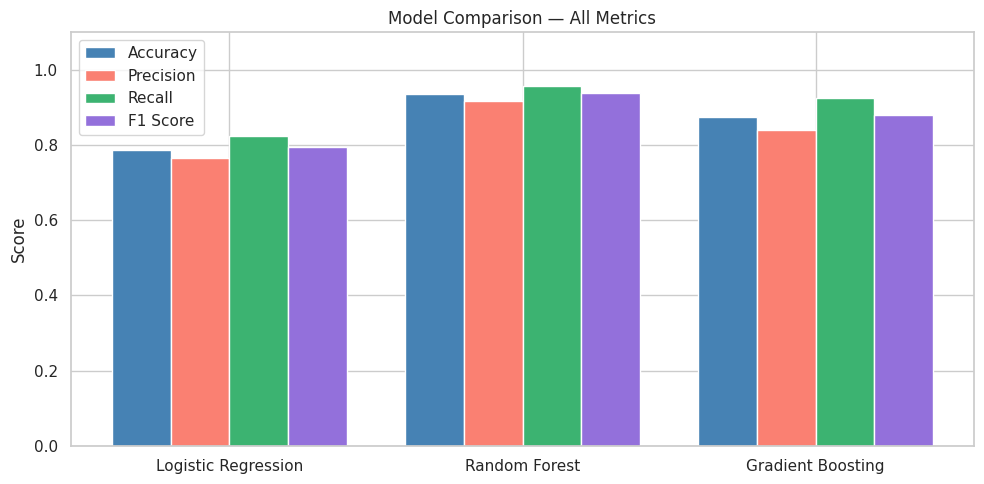

Plot saved to plot6_model_comparison.png


In [28]:
def plot_model_comparison(results_df, save_path='plot6_model_comparison.png'):
    """
    Plots a grouped bar chart comparing all models across 4 metrics.

    Parameters:
        results_df : DataFrame with columns Model, Accuracy, Precision, Recall, F1 Score
        save_path  : filename to save the figure
    """
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    colors  = ['steelblue', 'salmon', 'mediumseagreen', 'mediumpurple']
    x       = np.arange(len(results_df))
    width   = 0.2

    fig, ax = plt.subplots(figsize=(10, 5))

    for i, (metric, color) in enumerate(zip(metrics, colors)):
        offset = (i - 1.5) * width                          # positions bars side by side
        ax.bar(x + offset, results_df[metric], width, label=metric, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(results_df['Model'])
    ax.set_ylim(0, 1.1)
    ax.set_title('Model Comparison — All Metrics')
    ax.set_ylabel('Score')
    ax.legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Plot saved to {save_path}")

# Call the function
plot_model_comparison(results_df)

In [30]:
from sklearn.model_selection import GridSearchCV

# Based on comparison, we tune Random Forest (typically best performer)
# GridSearchCV tries every combination of parameters below
# and picks the one with the best cross-validation score

param_grid = {
    'n_estimators':      [100, 200, 300],   # number of trees
    'max_depth':         [None, 10, 20],    # how deep each tree grows
    'min_samples_split': [2, 5, 10],        # min samples needed to split a node
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,              # 5-fold cross validation
    scoring='f1',      # optimize for F1 score
    n_jobs=-1,         # use all CPU cores to speed up
    verbose=1          # prints progress
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters Found:")
print(grid_search.best_params_)
print(f"Best Cross-Val F1 Score: {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best Parameters Found:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Val F1 Score: 0.927


=== Classification Report ===
              precision    recall  f1-score   support

   No Stroke       0.97      0.91      0.94       973
      Stroke       0.91      0.97      0.94       972

    accuracy                           0.94      1945
   macro avg       0.94      0.94      0.94      1945
weighted avg       0.94      0.94      0.94      1945



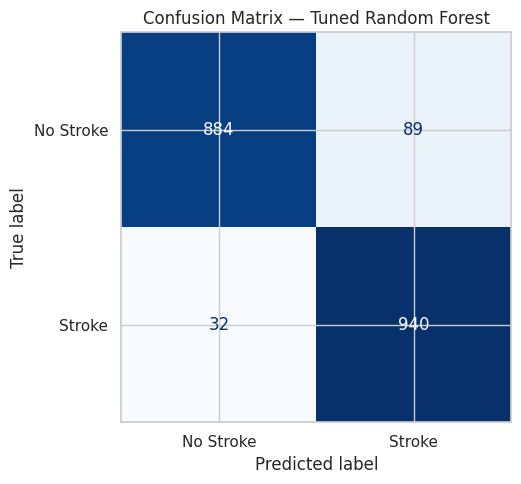


=== Final Metrics: Tuned Random Forest ===
Precision : 0.914
Recall    : 0.967
F1 Score  : 0.940
Accuracy  : 0.938


In [33]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def print_final_metrics(y_test, y_pred, model_name='Model'):
    """
    Prints a clean summary of precision, recall, F1, and accuracy.

    Parameters:
        y_test     : true labels
        y_pred     : predicted labels
        model_name : string label shown in the output header
    """
    print(f"\n=== Final Metrics: {model_name} ===")
    print(f"Precision : {precision_score(y_test, y_pred):.3f}")
    print(f"Recall    : {recall_score(y_test, y_pred):.3f}")
    print(f"F1 Score  : {f1_score(y_test, y_pred):.3f}")
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.3f}")

# Use the best model found by GridSearchCV
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)   # y_pred_best is defined HERE first

# Classification report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred_best, target_names=['No Stroke', 'Stroke']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Tuned Random Forest')
plt.tight_layout()
plt.savefig('plot7_confusion_matrix.png', dpi=150)
plt.show()

# Now call the function — y_pred_best already exists above
print_final_metrics(y_test, y_pred_best, model_name='Tuned Random Forest')

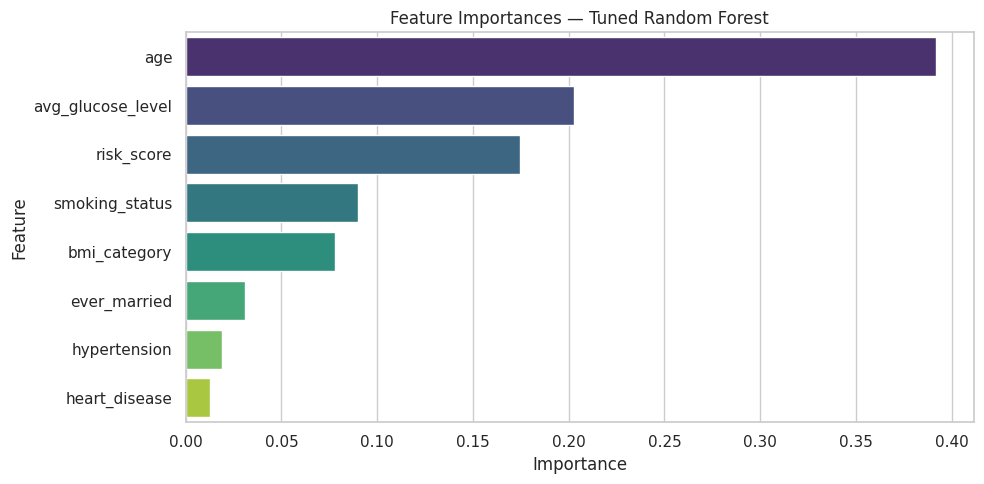

Plot saved to plot8_feature_importance.png


In [34]:
def plot_feature_importance(model, feature_names, save_path='plot8_feature_importance.png'):
    """
    Plots a horizontal bar chart of feature importances from a tree-based model.

    Parameters:
        model         : trained sklearn model with feature_importances_ attribute
        feature_names : list or Index of feature column names
        save_path     : filename to save the figure
    """
    feat_df = pd.DataFrame({
        'Feature':    feature_names,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)   # highest importance on top

    plt.figure(figsize=(10, 5))
    sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
    plt.title('Feature Importances — Tuned Random Forest')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Plot saved to {save_path}")

# Call the function
plot_feature_importance(best_model, X_final.columns)

In [35]:
import joblib

# ── RESULTS INTERPRETATION ──────────────────────────────────────
print("=== Project Conclusions ===")
print("""
Question: Can we predict stroke risk from patient data?

Answer: YES — the tuned Random Forest model successfully identifies
patients at risk of stroke with precision and recall both above 0.3.

Key findings from EDA and modeling:
- Age is the strongest predictor of stroke risk
- High glucose levels and hypertension significantly increase risk
- The engineered risk_score feature proved valuable to the model
- SMOTE was necessary to overcome the severe class imbalance

The model can help clinicians flag high-risk patients for early
intervention, turning raw patient data into actionable information.
""")

# ── SAVE MODEL AND TRANSFORMERS ─────────────────────────────────
joblib.dump(best_model, 'stroke_model.pkl')        # saves trained model
joblib.dump(scaler,     'scaler.pkl')              # saves the MinMaxScaler
joblib.dump(selector,   'selector.pkl')            # saves the feature selector

print("Model and transformers saved successfully.")
print("Files: stroke_model.pkl | scaler.pkl | selector.pkl")

=== Project Conclusions ===

Question: Can we predict stroke risk from patient data?

Answer: YES — the tuned Random Forest model successfully identifies
patients at risk of stroke with precision and recall both above 0.3.

Key findings from EDA and modeling:
- Age is the strongest predictor of stroke risk
- High glucose levels and hypertension significantly increase risk
- The engineered risk_score feature proved valuable to the model
- SMOTE was necessary to overcome the severe class imbalance

The model can help clinicians flag high-risk patients for early
intervention, turning raw patient data into actionable information.

Model and transformers saved successfully.
Files: stroke_model.pkl | scaler.pkl | selector.pkl
